<a href="https://colab.research.google.com/github/OJB-Quantum/Navaho-Linguistics/blob/main/Python%20Scripts%20for%20Navaho%20Linguistics/Navajo_Text_to_Unicode_Braille_to_DXF_and_GDS_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install gdstk ezdxf matplotlib

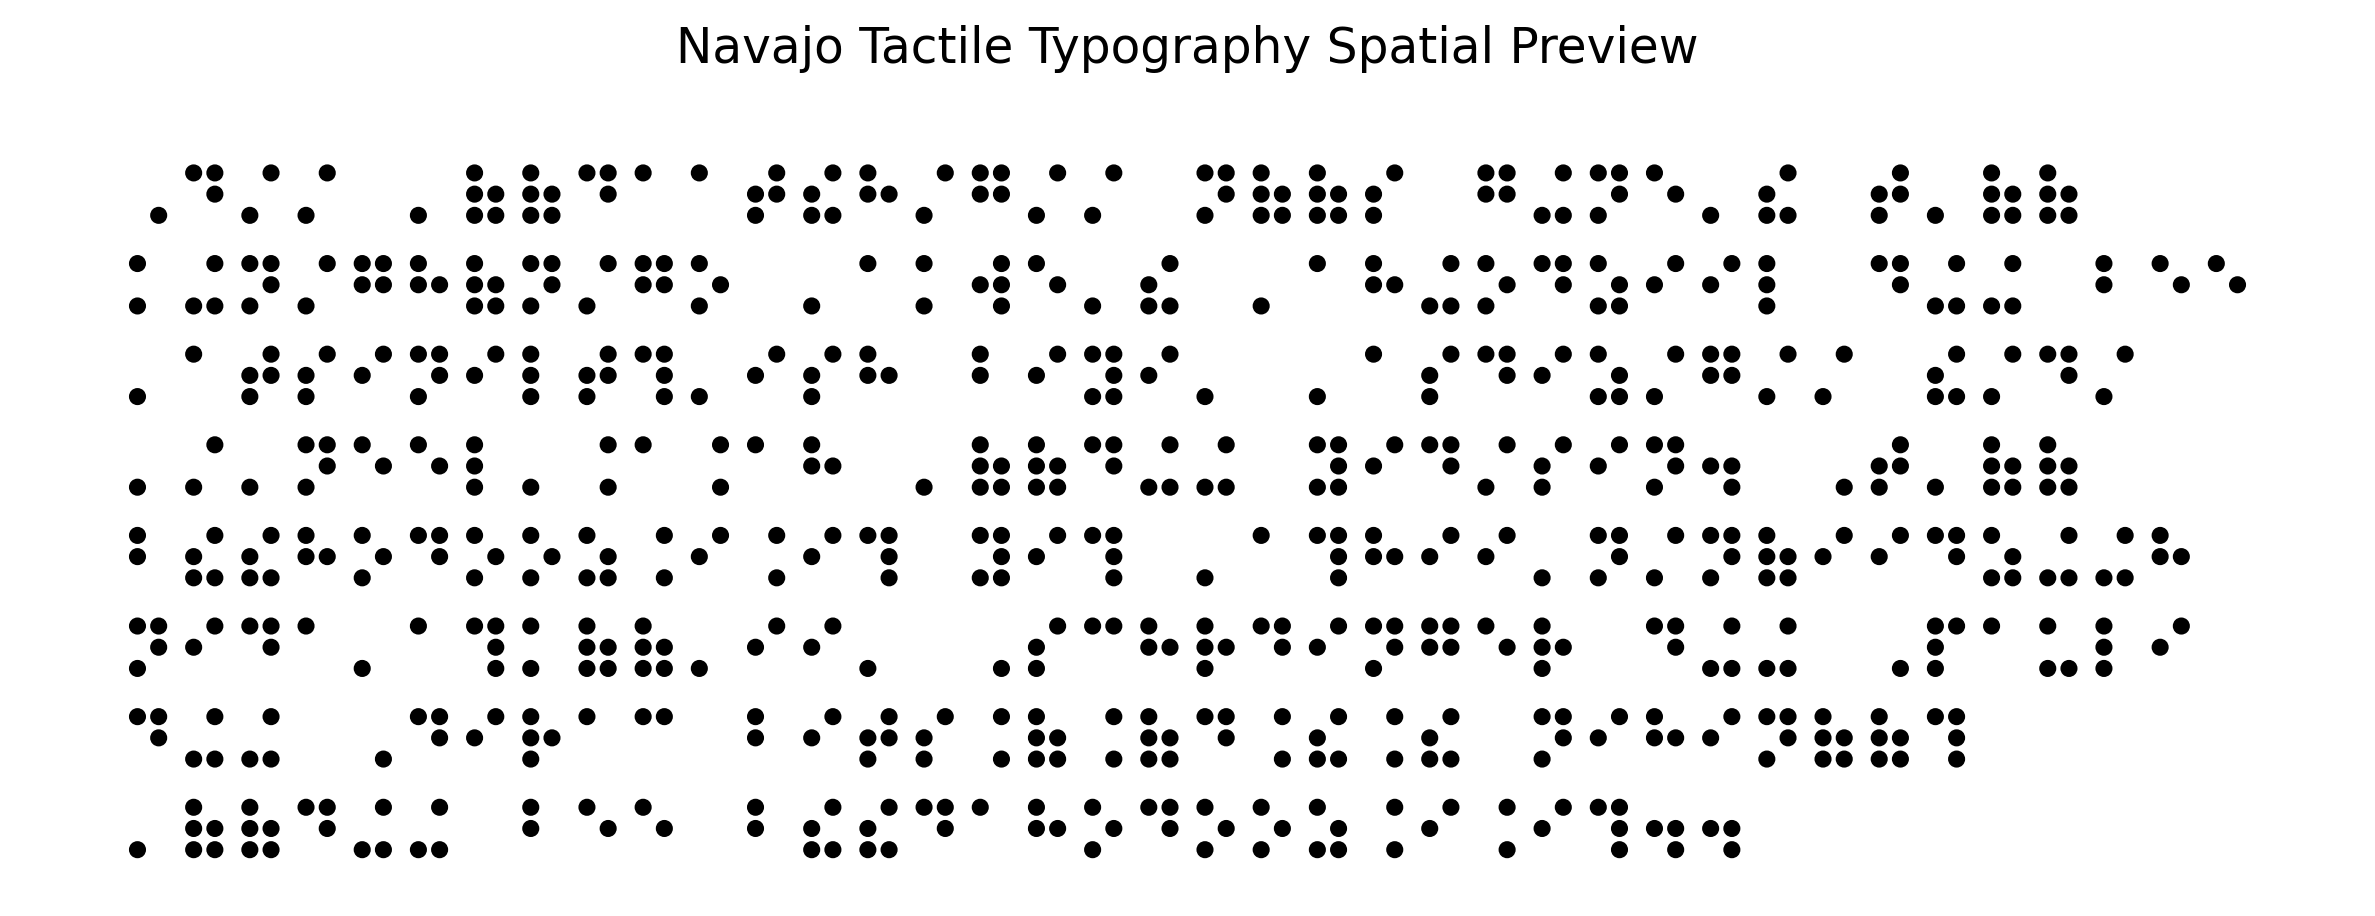

In [3]:
"""This script parses Navajo text into Braille Unicode and generates precise geometric formats for manufacturing."""

import unicodedata
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
import gdstk
import ezdxf

# ---------------------------------------------------
# Control Knobs
# ---------------------------------------------------
DOT_DIAMETER_MM = 1.5
DOT_RADIUS_MM = DOT_DIAMETER_MM / 2.0
DOT_SPACING_MM = 2.34
CHAR_SPACING_MM = 6.20
LINE_SPACING_MM = 10.00
MAX_CHARS_PER_LINE = 38
DPI_SETTING = 250
# 38 Braille characters were chosen per line because it fits on the printing bed of a Prusa MK3S

INPUT_NAVAJO_TEXT = "Díí 'áʼádaatʼéhígíí náás góne'é t'áá kóníghánígo 'akwe'é 'ahóodziil dóó bee 'atsiniltł'ish biyi' 'asdizígíí éídí 'í'neel'ąąh 'áádóó yidísin. T'áá bééhodoozįįł yił 'ałhii'níná’iidzóóh nida'ałkáá'ii' Schrödinger dóó Pauli dóó Dirac bits’ą́ą́dę́ę́ nihinááł 'áádóó bee béédahodoozįįł.."

# ---------------------------------------------------
# Linguistic Mapping Parameters
# ---------------------------------------------------
NAVAJO_BRAILLE_MAP = {
    "ą́": "⠨⠷", "ę́": "⠨⠮", "į́": "⠨⠌", "ǫ́": "⠨⠬",
    "ą": "⠨⠁", "ę": "⠨⠑", "į": "⠨⠊", "ǫ": "⠨⠕",
    "á": "⠷", "é": "⠮", "í": "⠌", "ó": "⠬",
    "ł": "⠹", "'": "⠄", ".": "⠲", ",": "⠂",
    "?": "⠦", "!": "⠖", " ": " ",
    "a": "⠁", "b": "⠃", "c": "⠉", "d": "⠙", "e": "⠑",
    "f": "⠋", "g": "⠛", "h": "⠓", "i": "⠊", "j": "⠚",
    "k": "⠅", "l": "⠇", "m": "⠍", "n": "⠝", "o": "⠕",
    "p": "⠏", "q": "⠟", "r": "⠗", "s": "⠎", "t": "⠞",
    "u": "⠥", "v": "⠧", "w": "⠺", "x": "⠭", "y": "⠽",
    "z": "⠵"
}

def translate_navajo_to_braille(text):
    """Translates standard Navajo orthography into Navajo Braille Unicode strings."""
    normalized_text = unicodedata.normalize('NFC', text)
    braille_output = ""

    skip_next = False
    for i, char in enumerate(normalized_text):
        if skip_next:
            skip_next = False
            continue

        if char.isupper():
            braille_output += "⠠"
            char = char.lower()

        if i < len(normalized_text) - 1:
            digraph = char + normalized_text[i+1].lower()
            if digraph in NAVAJO_BRAILLE_MAP:
                braille_output += NAVAJO_BRAILLE_MAP[digraph]
                skip_next = True
                continue

        if char in NAVAJO_BRAILLE_MAP:
            braille_output += NAVAJO_BRAILLE_MAP[char]

    return braille_output

def parse_braille_to_coordinates(text, max_chars_per_line):
    """Parses Braille Unicode and returns a list of Cartesian coordinates."""
    lines = []

    for paragraph in text.split('\n'):
        words = paragraph.split(' ')
        current_line = []
        current_length = 0
        for word in words:
            if current_length + len(word) > max_chars_per_line and current_line:
                lines.append(' '.join(current_line))
                current_line = [word]
                current_length = len(word) + 1
            else:
                current_line.append(word)
                current_length += len(word) + 1
        if current_line:
            lines.append(' '.join(current_line))

    dots = []

    for line_idx, line in enumerate(lines):
        y_offset = -line_idx * LINE_SPACING_MM
        for char_idx, char in enumerate(line):
            x_offset = char_idx * CHAR_SPACING_MM
            if not char.strip():
                continue

            unicode_val = ord(char)
            if 0x2800 <= unicode_val <= 0x28FF:
                offset_val = unicode_val - 0x2800

                if offset_val & 1:
                    dots.append((x_offset, y_offset + 2 * DOT_SPACING_MM))
                if offset_val & 2:
                    dots.append((x_offset, y_offset + 1 * DOT_SPACING_MM))
                if offset_val & 4:
                    dots.append((x_offset, y_offset))
                if offset_val & 8:
                    dots.append((x_offset + DOT_SPACING_MM, y_offset + 2 * DOT_SPACING_MM))
                if offset_val & 16:
                    dots.append((x_offset + DOT_SPACING_MM, y_offset + 1 * DOT_SPACING_MM))
                if offset_val & 32:
                    dots.append((x_offset + DOT_SPACING_MM, y_offset))
                if offset_val & 64:
                    dots.append((x_offset, y_offset - DOT_SPACING_MM))
                if offset_val & 128:
                    dots.append((x_offset + DOT_SPACING_MM, y_offset - DOT_SPACING_MM))

    return dots

def generate_manufacturing_files(dot_coordinates):
    """Generates the requisite DXF and GDSII geometries from numerical data."""
    lib = gdstk.Library()
    cell = lib.new_cell("BRAILLE_LAYOUT")
    for center_x, center_y in dot_coordinates:
        circle = gdstk.ellipse((center_x, center_y), DOT_RADIUS_MM, DOT_RADIUS_MM)
        cell.add(circle)

    lib.write_gds("navajo_braille_output.gds")

    doc = ezdxf.new("R2010")
    msp = doc.modelspace()
    for center_x, center_y in dot_coordinates:
        msp.add_circle((center_x, center_y), radius=DOT_RADIUS_MM)

    doc.saveas("navajo_braille_output.dxf")

def render_preview(dot_coordinates):
    """Renders the spatial geometry strictly within system memory."""
    plt.rcParams["figure.dpi"] = DPI_SETTING
    plt.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
    plt.rcParams["font.weight"] = "normal"

    fig, ax = plt.subplots(figsize=(12, 6))
    for center_x, center_y in dot_coordinates:
        circle = patches.Circle(
            (center_x, center_y),
            radius=DOT_RADIUS_MM,
            color="black"
        )
        ax.add_patch(circle)

    ax.set_aspect("equal")
    ax.autoscale_view()
    plt.axis("off")
    plt.title("Navajo Tactile Typography Spatial Preview", fontsize=14, pad=20)

    plt.show()
    plt.close(fig)

if __name__ == "__main__":
    translated_braille = translate_navajo_to_braille(INPUT_NAVAJO_TEXT)
    calculated_coordinates = parse_braille_to_coordinates(translated_braille, MAX_CHARS_PER_LINE)
    generate_manufacturing_files(calculated_coordinates)
    render_preview(calculated_coordinates)